# Постановка задачи

В рамках курса рассматривается задача анализа пользовательского поведения в e commerce с целью повышения конверсии и эффективности маркетинга.

Основная идея заключается в том, чтобы на основе действий пользователя на платформе определить, совершит ли он покупку. Это позволяет бизнесу более точно работать с аудиторией, снижать затраты на рекламу и увеличивать выручку.

---

## Бизнес постановка задачи

Необходимо предсказать, совершит ли пользователь покупку товара на сайте интернет магазина на основе его поведения.

Решение данной задачи позволяет:

- повысить конверсию за счет персонализированных предложений  
- оптимизировать маркетинговые расходы  
- выделить пользователей с высоким потенциалом покупки  
- снизить количество нерелевантных коммуникаций  

Таким образом, модель может быть использована для таргетинга, рекомендаций и приоритизации пользователей в маркетинговых кампаниях.

---

## ML постановка задачи

Задача формализуется как задача бинарной классификации.

Целевая переменная:

- 1 пользователь совершил покупку  
- 0 пользователь не совершил покупку  

На вход модели подаются признаки, отражающие поведение пользователя на сайте, такие как просмотры товаров, добавления в корзину и другие действия.

Цель модели заключается в оценке вероятности совершения покупки пользователем.

---

## Набор данных

Для решения задачи используется датасет  
E Commerce Dataset (RetailRocket)

Источник:  
https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset  

Датасет содержит события пользователей интернет магазина и включает следующие типы действий:

- view просмотр товара  
- addtocart добавление товара в корзину  
- transaction совершение покупки  

Каждая запись содержит:

- идентификатор пользователя  
- идентификатор товара  
- временную метку события  
- тип события  
- категорию товара  

Данные имеют событийную структуру, где один пользователь может совершать множество действий в рамках одной или нескольких сессий.

---

## Особенности данных

Датасет уже представлен в компактном виде и не требует дополнительного уменьшения объема.

Структура данных позволяет анализировать поведение пользователей и строить признаки на основе их активности, такие как количество просмотров, добавлений в корзину и покупок.

---

## Формирование целевой переменной

Целевая переменная формируется на уровне пользователя.

Если пользователь совершил хотя бы одну покупку, ему присваивается значение 1.

Если пользователь только просматривал товары или добавлял их в корзину, но не совершил покупку, ему присваивается значение 0.

Таким образом, задача сводится к прогнозированию вероятности покупки на основе пользовательской активности.

---

## Выбор метрик качества

В рамках задачи предсказания покупки используется метрика F1 score в качестве основной.

Выбор данной метрики обусловлен тем, что данные имеют выраженный дисбаланс классов, так как доля пользователей, совершающих покупку, значительно ниже доли пользователей без покупки. В таких условиях метрика accuracy может давать некорректную оценку качества модели.

F1 score позволяет учитывать как precision, так и recall, что важно с точки зрения бизнеса. С одной стороны, необходимо минимизировать ложные срабатывания, чтобы не тратить ресурсы на нерелевантные предложения. С другой стороны, важно не упускать потенциальных покупателей, что напрямую влияет на выручку.

Дополнительно используется метрика ROC-AUC для оценки способности модели различать классы на различных порогах и качества ранжирования пользователей по вероятности покупки.

---

**Загрузка**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

events = pd.read_csv('events.csv')
events.head(20)

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
5,1433224086234,972639,view,22556,NaN
6,1433221923240,810725,view,443030,NaN
7,1433223291897,794181,view,439202,NaN
8,1433220899221,824915,view,428805,NaN
9,1433221204592,339335,view,82389,NaN


### Общая характеристика данных

Датасет содержит информацию о действиях пользователей в интернет магазине. Каждая строка представляет собой отдельное событие взаимодействия пользователя с товаром.

В данных представлены следующие типы признаков:

- временной признак **timestamp**  
- идентификатор пользователя **visitorid**   
- тип события **event**   
- идентификатор товара **itemid**   

---

**Названия колонок**

In [2]:
list(events.columns)

['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']

---

**Базовая статистика**

In [3]:
events.shape

(2756101, 5)

In [4]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


In [5]:
events.describe()

,timestamp,visitorid,itemid,transactionid
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000


In [6]:
events.isna().sum()

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

In [7]:
events.nunique()

timestamp        2750455
visitorid        1407580
event                  3
itemid            235061
transactionid      17672
dtype: int64

### Базовая статистика

Датасет содержит большое количество наблюдений, что позволяет проводить устойчивый анализ пользовательского поведения.

В данных представлены как числовые, так и категориальные признаки. Основные числовые признаки связаны с идентификаторами пользователей и товаров, а также временной меткой событий.

Пропуски присутствуют только в поле transactionid, что является ожидаемым, так как данный признак заполняется исключительно для событий покупки.

Количество уникальных пользователей значительно превышает количество пользователей, совершивших покупки, что указывает на наличие дисбаланса в данных.

Таким образом, структура данных соответствует реальным сценариям e commerce, а сами данные пригодны для дальнейшего анализа и построения модели.

---

**Уникальные пользователи по событиям**

In [8]:
events.groupby('event')['visitorid'].nunique()

event
addtocart        37722
transaction      11719
view           1404179
Name: visitorid, dtype: int64

**Распределения**

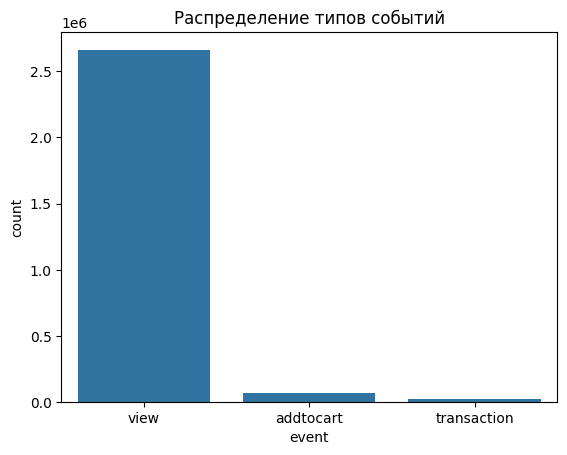

In [9]:
sns.countplot(x='event', data=events)
plt.title('Распределение типов событий')
plt.show()

In [10]:
events['event'].value_counts(normalize=True)

event
view           0.966696
addtocart      0.025156
transaction    0.008148
Name: proportion, dtype: float64

### Распределение типов событий

Анализ распределения событий показывает, что основную долю составляют просмотры товаров.

Количество уникальных пользователей по типам событий:
- view — 1 404 179 пользователей  
- addtocart — 37 722 пользователей  
- transaction — 11 719 пользователей  

Таким образом, лишь небольшая часть пользователей переходит от просмотра к добавлению в корзину, и еще меньшая — к покупке.

Это указывает на наличие выраженной воронки и значительных потерь пользователей на каждом этапе.

Наблюдается сильный дисбаланс событий, где просмотры доминируют над покупками, что является типичной ситуацией для e commerce систем.

Данный фактор необходимо учитывать при построении модели, так как он напрямую влияет на выбор метрик и подход к обучению.

---

**Конверсия**

In [11]:
purchase_users = events[events['event'] == 'transaction']['visitorid'].nunique()
all_users = events['visitorid'].nunique()

purchase_users / all_users

0.00832563690873698

### Конверсия пользователей

Конверсия пользователей составляет 0.83 процента.
Это означает, что лишь небольшая доля пользователей совершает покупку, что является типичной ситуацией для e commerce

---

**Активность пользователей**

In [12]:
user_activity = events.groupby('visitorid').size()

user_activity.describe()

count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
dtype: float64

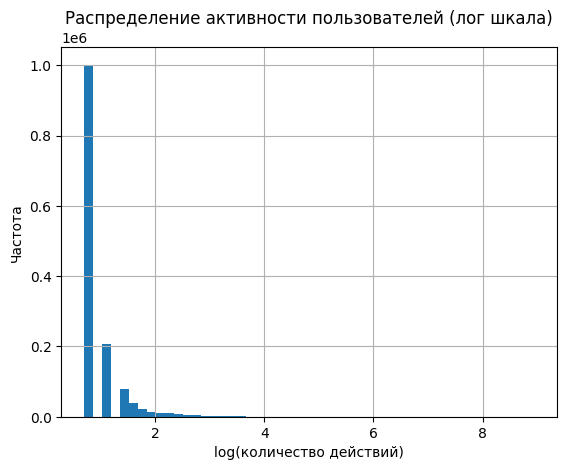

In [13]:
import numpy as np

np.log1p(user_activity).hist(bins=50)
plt.title('Распределение активности пользователей (лог шкала)')
plt.xlabel('log(количество действий)')
plt.ylabel('Частота')
plt.show()

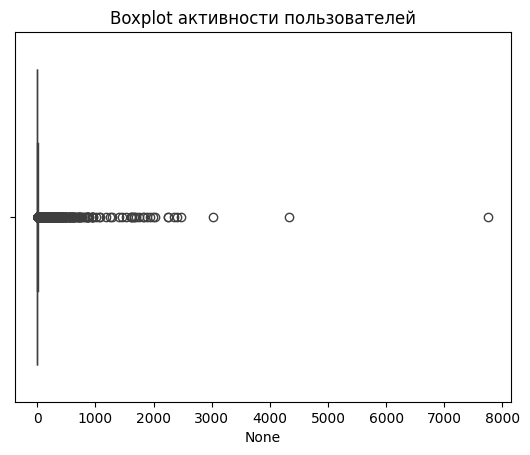

In [14]:
sns.boxplot(x=user_activity)
plt.title('Boxplot активности пользователей')
plt.show()

### Активность пользователей

Для более детального анализа распределения активности пользователей была применена логарифмическая шкала, что позволило сгладить влияние выбросов и лучше визуализировать основную массу данных.

Распределение показывает, что большинство пользователей совершают крайне небольшое количество действий, при этом основная плотность наблюдений сосредоточена в области низкой активности.

Boxplot подтверждает наличие значительного количества выбросов, что свидетельствует о присутствии небольшой группы пользователей с очень высокой активностью.

Таким образом, распределение активности является сильно скошенным, с длинным правым хвостом, что указывает на неоднородность пользовательского поведения.

Для дальнейшего анализа и построения модели целесообразно учитывать данную особенность данных, например, с помощью логарифмического преобразования признаков или выделения отдельных сегментов пользователей по уровню активности.

---

**Воронка**

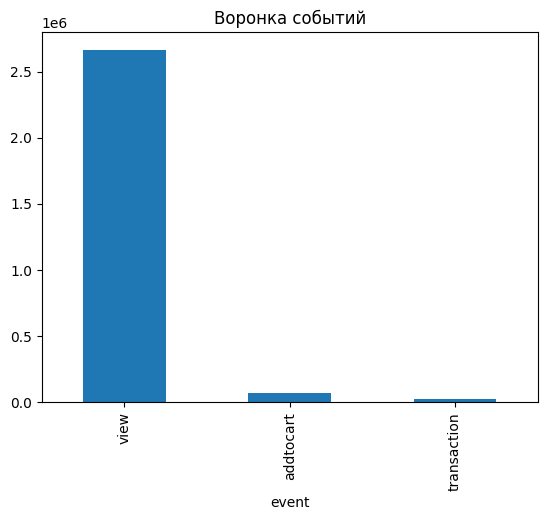

In [15]:
events['event'].value_counts().plot(kind='bar')
plt.title('Воронка событий')
plt.show()

### Анализ воронки

Анализ воронки событий показывает последовательное снижение количества пользователей на каждом этапе взаимодействия с платформой.

Наибольшее количество событий приходится на просмотры товаров, при этом значительно меньше пользователей добавляют товары в корзину, и еще меньшая часть совершает покупку.

Это указывает на наличие существенных потерь пользователей между этапами воронки, особенно на переходе от просмотра к добавлению в корзину.

Такая структура является типичной для e commerce систем, однако она также демонстрирует потенциал для оптимизации пользовательского пути.

С точки зрения бизнеса, улучшение конверсии на промежуточных этапах воронки может привести к значительному росту выручки.

Для построения модели важно учитывать этапы воронки и поведение пользователя на каждом из них.

---

**Топ товары**

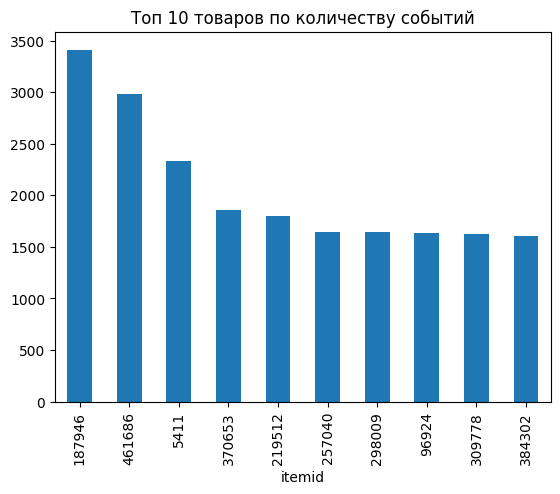

In [16]:
top_items = events['itemid'].value_counts().head(10)

top_items.plot(kind='bar')
plt.title('Топ 10 товаров по количеству событий')
plt.show()

### Популярные товары

Анализ наиболее популярных товаров показывает, что существует группа товаров, которые значительно выделяются по количеству взаимодействий пользователей.

Это может свидетельствовать о высокой популярности отдельных товаров или категорий, а также о влиянии внешних факторов, таких как акции, рекомендации или особенности ассортимента.

Наличие товаров с высокой частотой взаимодействий указывает на неравномерное распределение интереса пользователей.

---

**Временной анализ**

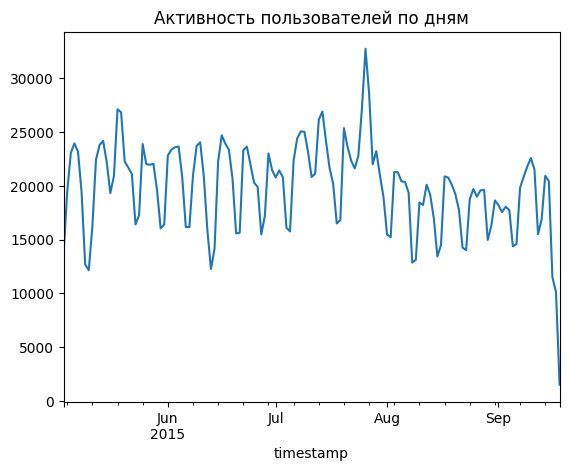

In [17]:
# приведение времени
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')

# делаем timestamp индексом
events = events.set_index('timestamp')

# строим график
events.resample('D').size().plot()
plt.title('Активность пользователей по дням')
plt.show()

### Временной анализ

Анализ активности пользователей во времени показывает наличие выраженных колебаний в течение всего рассматриваемого периода.

Наблюдаются регулярные изменения активности, что может быть связано с поведенческими паттернами пользователей, такими как различия между будними и выходными днями.

В отдельные периоды фиксируются всплески активности, что может быть обусловлено внешними факторами, например маркетинговыми акциями или сезонными событиями.

---

**Покупатели vs не покупатели**

In [18]:
buyers = events[events['event'] == 'transaction']['visitorid'].unique()
events['is_buyer'] = events['visitorid'].isin(buyers)

result = events['is_buyer'].value_counts(normalize=True) * 100

print(result)

is_buyer
False    91.630278
True      8.369722
Name: proportion, dtype: float64


### Покупатели и непокупатели

Анализ распределения пользователей показывает, что подавляющее большинство пользователей не совершают покупку.

Количество событий для непокупателей значительно превышает количество событий для покупателей, что подтверждает наличие выраженного дисбаланса в данных.

---

**user-level таблица**

In [19]:
user_events = events.groupby(['visitorid', 'event']).size().unstack(fill_value=0)

user_events.head(20)

event,addtocart,transaction,view
visitorid,,,
0,0,0,3
1,0,0,1
2,0,0,8
3,0,0,1
4,0,0,1
5,0,0,1
6,1,0,5
7,0,0,3
8,0,0,1


### Формирование признаков на уровне пользователя

Для дальнейшего анализа была построена агрегированная таблица на уровне пользователей, в которой отражено количество различных типов событий для каждого пользователя.

Такая структура данных позволяет перейти от событийного уровня к пользовательскому, что является необходимым этапом для построения модели.

Полученные признаки отражают поведение пользователя, например:
- количество просмотров товаров  
- количество добавлений в корзину  
- количество покупок  

Анализ таблицы показывает, что у большинства пользователей отсутствуют покупки, при этом активность в виде просмотров значительно преобладает.

---

**Связь просмотров и покупок**

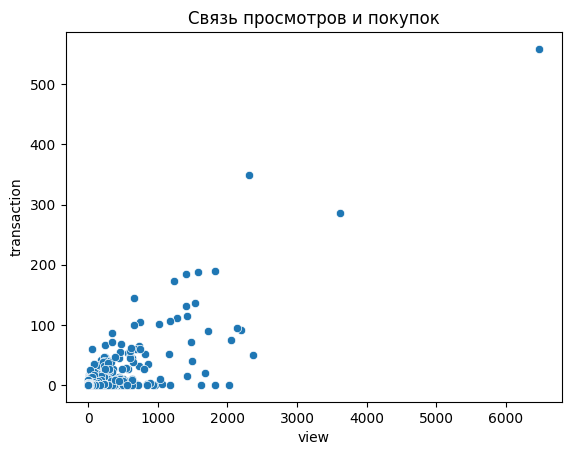

In [20]:
sns.scatterplot(x=user_events['view'], y=user_events.get('transaction', 0))
plt.title('Связь просмотров и покупок')
plt.show()

### Связь просмотров и покупок

Анализ зависимости между количеством просмотров и покупок показывает наличие положительной связи между данными показателями.

С увеличением количества просмотров наблюдается рост числа покупок, что подтверждает гипотезу о том, что более вовлеченные пользователи имеют более высокую вероятность совершения покупки.

При этом зависимость не является строго линейной, что указывает на влияние дополнительных факторов на поведение пользователей.


## Формирование целевой переменной

Целевая переменная формируется на уровне пользователя.

Если пользователь совершил хотя бы одну покупку, значение target равно 1.  
Если пользователь не совершал покупок, значение равно 0.


In [21]:
# target
user_events['target'] = (user_events['transaction'] > 0).astype(int)

user_events.head()

event,addtocart,transaction,view,target
visitorid,,,,
0,0,0,3,0
1,0,0,1,0
2,0,0,8,0
3,0,0,1,0
4,0,0,1,0


### Обоснование выбора признаков

Для построения модели использовались агрегированные пользовательские признаки:
- количество просмотров (view)
- количество добавлений в корзину (addtocart)

Признак `transaction` используется как целевая переменная (совершил ли пользователь покупку).

Такой подход позволяет перейти от событийного уровня к пользовательскому,
что является стандартной практикой при построении моделей поведения пользователей

In [29]:
X = user_events[['view', 'addtocart']]   # убираем transaction
y = (user_events['transaction'] > 0).astype(int)

## Разбиение на обучающую и тестовую выборки

Данные разделены на обучающую и тестовую выборки в соотношении 80/20.

Используется стратификация по целевой переменной, чтобы сохранить распределение классов.


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Выбор метрик качества

В качестве основной метрики используется F1 score.

Данные имеют выраженный дисбаланс классов, поэтому accuracy не подходит.

Дополнительно используется ROC AUC для оценки способности модели различать классы.

In [31]:
from sklearn.metrics import f1_score, roc_auc_score

## Константная модель

В качестве базового ориентира используется константная модель — DummyClassifier.

Данная модель всегда предсказывает наиболее частый класс в обучающей выборке

In [32]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("F1 baseline:", f1_score(y_test, y_pred_dummy))

F1 baseline: 0.0


## Логистическая регрессия

В качестве базовой модели была выбрана логистическая регрессия.

Данная модель является простой и интерпретируемой, что позволяет
использовать её как отправную точку для оценки качества.

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

print("F1 Logistic:", f1_score(y_test, y_pred_lr))
print("ROC AUC Logistic:", roc_auc_score(y_test, y_proba_lr))

F1 Logistic: 0.1423090338332752
ROC AUC Logistic: 0.9642215551091626




Результаты на тестовой выборке:
- F1 ≈ 0.14
- ROC AUC ≈ 0.96

In [34]:
print(X.columns)

Index(['view', 'addtocart'], dtype='object', name='event')


## Случайный лес

В качестве более сложной модели выбран алгоритм Random Forest.

Данный метод относится к ансамблевым моделям и объединяет множество решающих деревьев,
что позволяет повысить качество предсказаний по сравнению с одиночными моделями.

Выбор Random Forest обусловлен следующими причинами:
- способен учитывать нелинейные зависимости между признаками
- устойчив к выбросам и шуму в данных

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("F1 RF:", f1_score(y_test, y_pred_rf))
print("ROC AUC RF:", roc_auc_score(y_test, y_proba_rf))

F1 RF: 0.11001517450682853
ROC AUC RF: 0.9667285374219005


## Подбор гиперпараметров

Для улучшения качества модели Random Forest был выполнен подбор гиперпараметров.

Оптимизировались следующие параметры:

- `n_estimators` — количество деревьев в ансамбле. Увеличение этого параметра повышает стабильность модели и снижает дисперсию.
- `max_depth` — максимальная глубина деревьев. Позволяет контролировать переобучение: слишком глубокие деревья могут переобучаться.

Подбор осуществлялся с помощью GridSearchCV с кросс-валидацией (cv=3),
что позволяет получить более устойчивую оценку качества модели.

В качестве метрики оптимизации выбран F1-score,
так как данные имеют выраженный дисбаланс классов.

Модель Random Forest выбрана, так как:
- хорошо работает с табличными данными
- учитывает нелинейные зависимости
- не требует масштабирования признаков
- устойчива к выбросам

Предобработка данных минимальна:
- признаки агрегированы до уровня пользователя
- категориальные признаки отсутствуют
- масштабирование не требуется

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("Best params:", grid.best_params_)
print("F1 tuned:", f1_score(y_test, y_pred_best))
print("ROC AUC tuned:", roc_auc_score(y_test, y_proba_best))

Best params: {'max_depth': None, 'n_estimators': 50}
F1 tuned: 0.10742857142857143
ROC AUC tuned: 0.9667361453963645


## Глобальная интерпретация модели

Анализ важности признаков показывает,
что наибольший вклад в предсказание покупки вносят:

- количество добавлений в корзину (addtocart)
- количество просмотров (view)

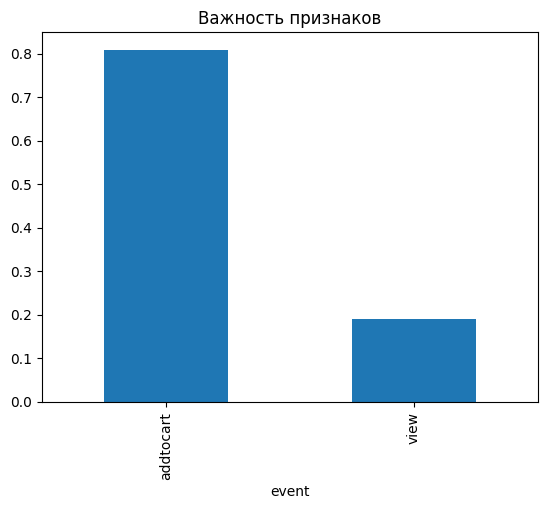

In [37]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances.plot(kind='bar')
plt.title('Важность признаков')
plt.show()

## Вывод по глобальной интерпретации модели

Анализ важности признаков показал, что наибольший вклад в предсказание покупки вносит признак `addtocart`.

Это означает, что добавление товара в корзину является ключевым фактором,
определяющим вероятность совершения покупки.

Признак `view` также оказывает влияние, однако его вклад существенно ниже.
Это говорит о том, что простые просмотры товаров не всегда приводят к покупке
и являются менее информативным сигналом.

## Локальная интерпретация

Используется SHAP для объяснения отдельных предсказаний

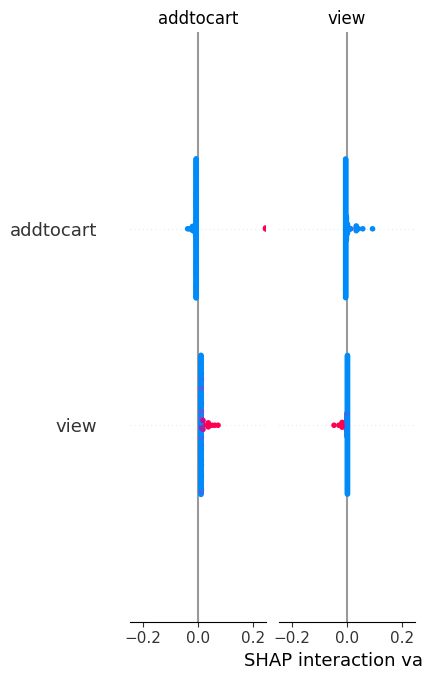

In [43]:
import shap

explainer = shap.TreeExplainer(best_model)


X_sample = X_test.sample(200, random_state=42)

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_sample)
else:
    shap.summary_plot(shap_values, X_sample)

## Вывод по локальной интерпретации (SHAP)

Анализ SHAP-значений показывает вклад признаков в предсказание модели на уровне отдельных наблюдений.

На графике видно, что:
- признак `addtocart` оказывает наибольшее влияние на предсказание
- высокие значения `addtocart` увеличивают вероятность покупки
- признак `view` оказывает меньшее влияние и имеет более слабую зависимость с целевой переменной

Таким образом, модель в основном опирается на действия пользователей,
связанные с добавлением товара в корзину, что отражает реальное поведение покупателе